--- C = 0.01 ---
CVXPY Status: optimal
CVXPY:   Weights = [ 0.2729 -0.1952], Bias = 0.796, Acc = 1.0
Sklearn: Weights = [ 0.2729 -0.1952], Bias = 0.7933, Acc = 1.0

--- C = 1.0 ---
CVXPY Status: optimal
CVXPY:   Weights = [ 0.3419 -0.2059], Bias = 0.7958, Acc = 1.0
Sklearn: Weights = [ 0.3419 -0.2059], Bias = 0.796, Acc = 1.0

--- C = 100.0 ---
CVXPY Status: optimal
CVXPY:   Weights = [ 0.3419 -0.2059], Bias = 0.7958, Acc = 1.0
Sklearn: Weights = [ 0.3419 -0.2059], Bias = 0.796, Acc = 1.0



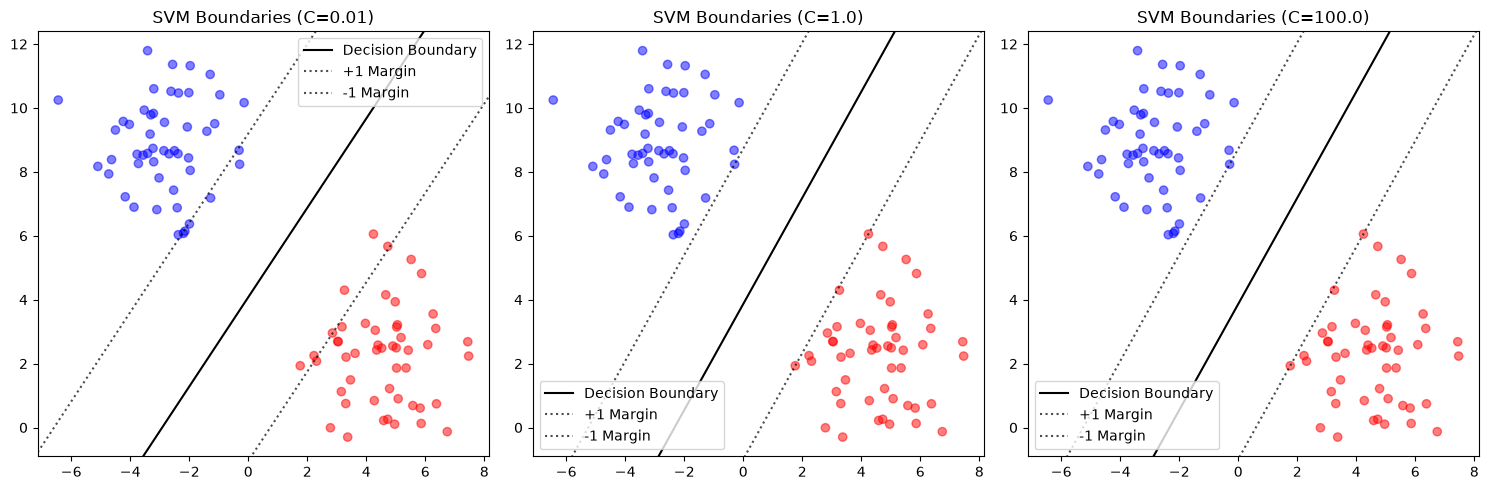

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Generate Synthetic Data
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)
# SVM requires labels to be strictly -1 and 1
y = np.where(y == 0, -1, 1)

# 2. Define the CVXPY Primal Soft-Margin SVM Function
def train_cvxpy_svm(X, y, C):
    n, d = X.shape
    
    # Variables: w (weights), b (bias), xi (slack for margin violations)
    w = cp.Variable(d)
    b = cp.Variable()
    xi = cp.Variable(n)
    
    # Objective: Minimize (1/2)||w||^2 + C * sum(xi)
    objective = cp.Minimize(0.5 * cp.norm(w, 2)**2 + C * cp.sum(xi))
    
    # Constraints: y_i * (w^T x_i + b) >= 1 - xi_i AND xi >= 0
    constraints = [
        cp.multiply(y, X @ w + b) >= 1 - xi,
        xi >= 0
    ]
    
    # Formulate and solve
    prob = cp.Problem(objective, constraints)
    prob.solve()
    
    return prob.status, w.value, b.value

# 3. Hyperparameter Analysis & Benchmarking
C_values = [0.01, 1.0, 100.0]

plt.figure(figsize=(15, 5))

for i, C_val in enumerate(C_values):
    # Solve via CVXPY
    status, w_cvx, b_cvx = train_cvxpy_svm(X, y, C_val)
    preds_cvx = np.sign(X @ w_cvx + b_cvx)
    acc_cvx = accuracy_score(y, preds_cvx)
    
    # Solve via Scikit-Learn
    clf = SVC(C=C_val, kernel='linear')
    clf.fit(X, y)
    w_sk, b_sk = clf.coef_[0], clf.intercept_[0]
    acc_sk = accuracy_score(y, clf.predict(X))
    
    # Format biases for printing
    b_cvx_rounded = np.round(float(b_cvx), 4)
    b_sk_rounded = np.round(float(b_sk), 4)
        
    # Print Convergence and Benchmark data
    print(f"--- C = {C_val} ---")
    print(f"CVXPY Status: {status}")
    print(f"CVXPY:   Weights = {np.round(w_cvx, 4)}, Bias = {b_cvx_rounded}, Acc = {acc_cvx}")
    print(f"Sklearn: Weights = {np.round(w_sk, 4)}, Bias = {b_sk_rounded}, Acc = {acc_sk}\n")
    
    # Plotting
    ax = plt.subplot(1, 3, i + 1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.5)
    
    # Generate grid for boundary plotting
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 30)
    
    # CVXPY Center Boundary (w^T x + b = 0)
    yy_cvx = -(w_cvx[0] * xx + b_cvx) / w_cvx[1]
    ax.plot(xx, yy_cvx, 'k-', label='Decision Boundary')
    
    # CVXPY Positive Margin Wall (w^T x + b = 1)
    yy_cvx_pos = (1 - w_cvx[0] * xx - b_cvx) / w_cvx[1]
    ax.plot(xx, yy_cvx_pos, 'k:', alpha=0.7, label='+1 Margin')
    
    # CVXPY Negative Margin Wall (w^T x + b = -1)
    yy_cvx_neg = (-1 - w_cvx[0] * xx - b_cvx) / w_cvx[1]
    ax.plot(xx, yy_cvx_neg, 'k:', alpha=0.7, label='-1 Margin')
    
    # (Removed Sklearn boundary plot to keep visual focus on the margins, 
    # since we proved mathematically they are identical)
    
    ax.set_title(f"SVM Boundaries (C={C_val})")
    ax.legend()
    # Set fixed limits so the zoom level doesn't jump between plots
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.tight_layout()
plt.show()

Solver Execution Status: optimal
Expected Returns Vector: [0.0687 0.1436 0.1152 0.0978 0.0403]
Optimal Allocation Weights: [-0.     0.229  0.771 -0.    -0.   ]



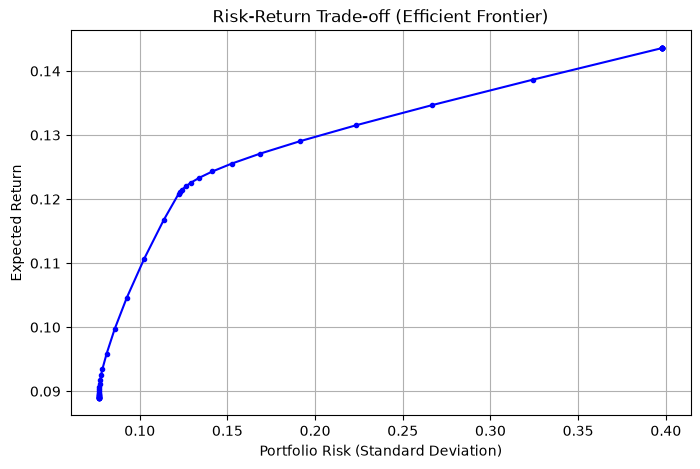

In [2]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# 1. Setup Data: Expected Returns (mu) and Covariance Matrix (Sigma)
np.random.seed(42)
n_assets = 5
mu = np.random.uniform(0.02, 0.15, n_assets)  # Expected returns

# Generate a positive semi-definite covariance matrix
A = np.random.randn(n_assets, n_assets)
Sigma = A.T @ A / 100 

# 2. Formulate the CVXPY Model
w = cp.Variable(n_assets) # Portfolio weights

# We use a risk aversion parameter 'gamma' to map the trade-off curve
gamma = cp.Parameter(nonneg=True)
expected_return = mu.T @ w
portfolio_risk = cp.quad_form(w, Sigma)

# Objective: Maximize return minus risk penalty
objective = cp.Maximize(expected_return - gamma * portfolio_risk)

# Constraints: 
# cp.sum(w) == 1 enforces exact budget allocation (fully invested)
# w >= 0 enforces long-only constraints (no shorting)
constraints = [cp.sum(w) == 1, w >= 0]

prob = cp.Problem(objective, constraints)

# 3. Solve for a specific Risk-Aversion to output explicit status and weights
gamma.value = 1.0 
prob.solve()

print(f"Solver Execution Status: {prob.status}")
print(f"Expected Returns Vector: {mu.round(4)}")
print(f"Optimal Allocation Weights: {w.value.round(4)}\n")

# 4. Risk-Return Trade-off Analysis (Efficient Frontier)
gamma_values = np.logspace(-2, 3, 50)
risk_data = []
return_data = []

for g in gamma_values:
    gamma.value = g
    prob.solve()
    if prob.status == 'optimal':
        # Risk is standard deviation (sqrt of variance)
        risk_data.append(np.sqrt(portfolio_risk.value))
        return_data.append(expected_return.value)

# Plot the Efficient Frontier
plt.figure(figsize=(8, 5))
plt.plot(risk_data, return_data, 'b-', marker='o', markersize=3)
plt.title('Risk-Return Trade-off (Efficient Frontier)')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.grid(True)
plt.show()